# **1. Import Libraries**

In [3]:
# --- Core Python Libraries ---
import os
import random
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# --- Image Handling ---
from PIL import Image

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Evaluation ---
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

import ipywidgets as widgets
from IPython.display import display

# **1.1 Initialize Path**

In [4]:
# Define the base directory for the dataset
base_path = 'C:/Users/awadh/Wheat/Rusts'

# Define the paths for the training and testing data
train_path = os.path.join(base_path, 'train')
test_path = os.path.join(base_path, 'test')

# **2. Preview Data**

In [5]:
# Get all classnames from directory
class_names = sorted(os.listdir(train_path))

print("Classes:", class_names)
print("Total number of classes:", len(class_names))

Classes: ['Black Rust', 'Brown Rust', 'Healthy', 'Yellow Rust']
Total number of classes: 4


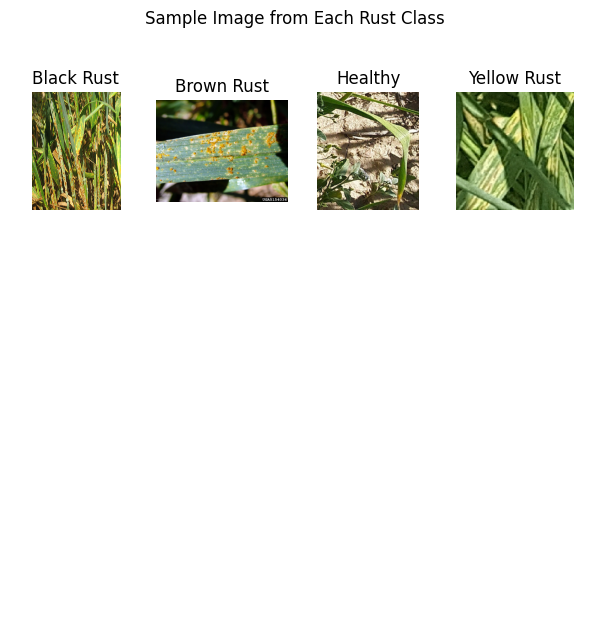

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle("Sample Image from Each Rust Class", fontsize=12, y=1.02)
axes = axes.ravel()

valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.jfif')

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_path, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_ext)]
    
    if image_files:
        image_path = os.path.join(class_dir, random.choice(image_files))
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=12)
        axes[i].axis("off")

for j in range(len(class_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# **3. Data Exploration**

In [5]:
# Count images per class
class_counts = {
    cls: len(os.listdir(os.path.join(train_path, cls)))
    for cls in class_names
}

# Create DataFrame sorted by count
df_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)
df_counts.insert(0, 'sl.no', range(1, 1 + len(df_counts)))

print("Image counts per class:")
print(df_counts.to_string(index=False))

# Total images
total_images = df_counts['Count'].sum()
print(f"\nTotal number of images: {total_images}")

Image counts per class:
 sl.no       Class  Count
     1     Healthy   1020
     2 Yellow Rust   1000
     3  Brown Rust    987
     4  Black Rust    933

Total number of images: 3940


# **4. Define and Load Data using Pipeline**

# 4.1 Preprocessing and Splitting Dataset 

In [6]:
# Image dimensions and batch size
img_width, img_height = 100, 100
batch_size = 32

# Data generator with normalization and train/validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data (20%)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Summary
print(f"Training images: {train_generator.n}")
print(f"Validation images: {validation_generator.n}")
print(f"Number of classes: {train_generator.num_classes}")

Found 2759 images belonging to 4 classes.
Found 1181 images belonging to 4 classes.
Training images: 2759
Validation images: 1181
Number of classes: 4


# 4.2 Data Augmentation

In [7]:
# Image dimensions and batch size
img_width, img_height = 100, 100
batch_size = 32

# Data generator with augmentation and validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.3
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation data (20%)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Summary
print(f"Training images: {train_generator.n}")
print(f"Validation images: {validation_generator.n}")
print(f"Number of classes: {train_generator.num_classes}")

Found 2759 images belonging to 4 classes.
Found 1181 images belonging to 4 classes.
Training images: 2759
Validation images: 1181
Number of classes: 4


# **5. Model Evaluation**

In [8]:
# Number of classes and image dimensions
num_classes = train_generator.num_classes
img_width, img_height = 100, 100

# Use MirroredStrategy for multi-GPU or robust device placement
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model = tf.keras.Sequential([
        # Convolutional blocks
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # Flatten and fully connected layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 32)      

In [9]:
# Define the number of training epochs
epochs = 200

# Early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=3,           
    restore_best_weights=True
)

# Start training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/200
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
86/86 [==============================] - 103s 1s/step - loss: 1.2788 - accuracy: 0.3953 - val_loss: 1.1046 - val_accuracy: 0.5052
Epoch 2/200
86/86 

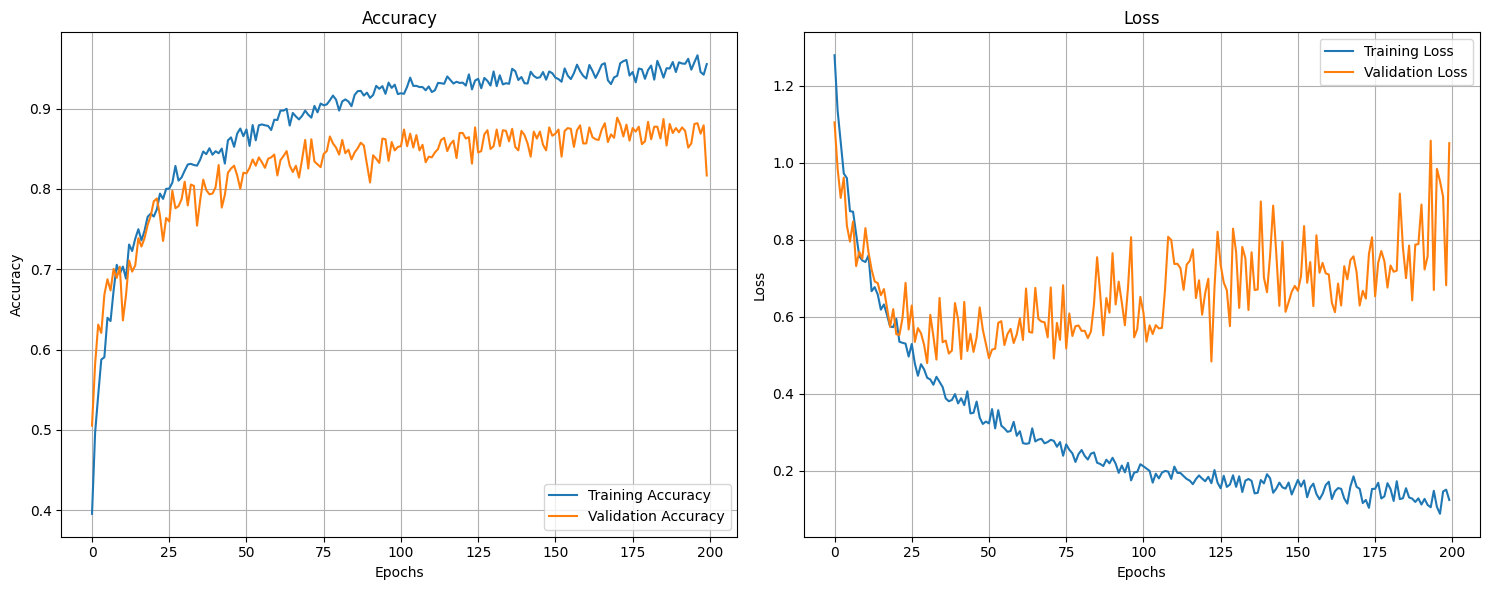

In [10]:
# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Plot training and validation accuracy & loss
plt.figure(figsize=(15, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Get the final validation metrics
final_accuracy = history.history['val_accuracy'][-1]
final_loss = history.history['val_loss'][-1]

print(f"Final Validation Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Loss: {final_loss:.4f}")

Final Validation Accuracy: 0.8168
Final Validation Loss: 1.0506


In [12]:
# Get the true labels and predicted labels for the validation set
validation_labels = validation_generator.classes
validation_steps = validation_generator.samples // validation_generator.batch_size
predictions = model.predict(validation_generator, steps=validation_steps)
predicted_labels = np.argmax(predictions, axis=1)

# Get the class labels from the generator
class_labels = list(validation_generator.class_indices.keys())

# Generate and print the classification report
report = classification_report(validation_labels[:len(predicted_labels)], predicted_labels, target_names=class_labels)
print("\nClassification Report:\n", report)

36/36 [==============================] - 28s 728ms/step

Classification Report:
               precision    recall  f1-score   support

  Black Rust       0.69      0.93      0.79       279
  Brown Rust       0.89      0.56      0.69       296
     Healthy       0.94      0.84      0.89       306
 Yellow Rust       0.84      0.98      0.90       271

    accuracy                           0.82      1152
   macro avg       0.84      0.83      0.82      1152
weighted avg       0.84      0.82      0.82      1152



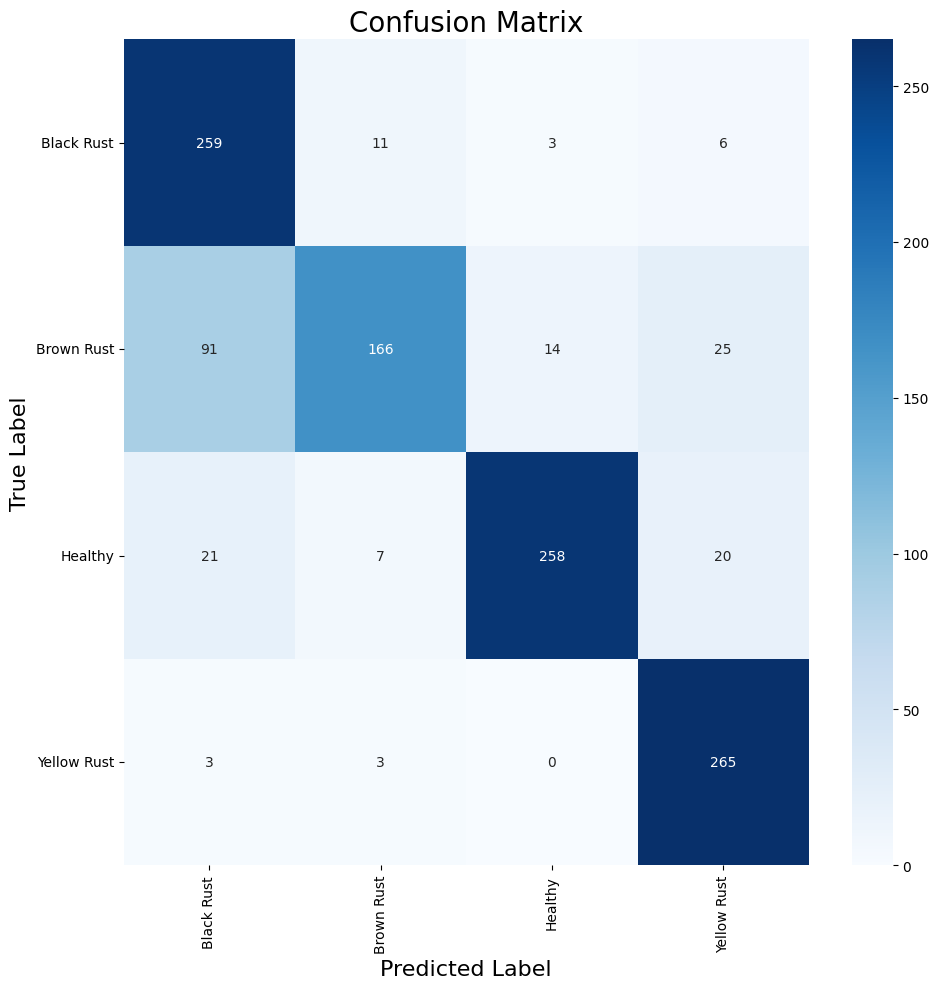

In [13]:
# Generate the confusion matrix
cm = confusion_matrix(validation_labels[:len(predicted_labels)], predicted_labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **6. Test model with Unseen Data**

In [14]:
# Save the model in the HDF5 (.h5) format
model.save('C:/Users/awadh/Wheat/my_rusts_model.h5')
print("Model saved successfully as 'my_rusts_model.h5'.")

Model saved successfully as 'my_rusts_model.h5'.


In [9]:
# -------------------------------
# IMPORTS
# -------------------------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display
from tensorflow.keras.models import load_model

# -------------------------------
# FORCE CPU (avoid transfer manager errors)
# -------------------------------
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# -------------------------------
# LOAD MODEL
# -------------------------------
model_path = 'C:/Users/awadh/Wheat/my_rusts_model.h5'
model = load_model(model_path, compile=False)

# -------------------------------
# CLASS LABELS
# -------------------------------
class_labels = ['Black Rust', 'Brown Rust', 'Healthy', 'Yellow Rust']

# -------------------------------
# IMAGE PREPROCESSING
# -------------------------------
def preprocess_image(image_path, target_size=(100, 100)):
    """Load image, resize, normalize and expand dimensions for prediction."""
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img).astype("float32") / 255.0
    return np.expand_dims(img_array, axis=0)

# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_image(img_path):
    """Predict and return figure + label instead of showing directly."""
    x = preprocess_image(img_path)
    x = tf.convert_to_tensor(x)

    with tf.device("/CPU:0"):
        preds = model(x, training=False).numpy()

    idx = np.argmax(preds, axis=1)[0]
    label = class_labels[idx]
    conf = preds[0][idx] * 100

    # Plot image
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(Image.open(img_path))
    ax.axis("off")
    ax.set_title(f"Predicted: {label} ({conf:.2f}%)", fontsize=12)

    # Return figure and details
    return fig, label, conf, os.path.basename(img_path)

# -------------------------------
# TEST IMAGE SEARCH
# -------------------------------
test_path = 'C:/Users/awadh/Wheat/Rusts/test'
valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.jfif')

# Search recursively for images in subfolders
image_files = []
for root, dirs, files in os.walk(test_path):
    for f in files:
        if f.lower().endswith(valid_ext):
            image_files.append(os.path.join(root, f))

# Relative paths for dropdown display
dropdown_options = [os.path.relpath(f, test_path) for f in image_files]

print(f"✅ Found {len(image_files)} images for prediction.")

# -------------------------------
# WIDGETS
# -------------------------------
dropdown = widgets.Dropdown(
    options=dropdown_options if dropdown_options else ["(no images found)"],
    description="Choose Image:",
    layout=widgets.Layout(width="60%")
)

count_box = widgets.BoundedIntText(
    value=1,
    min=1,
    max=max(1, len(image_files)),
    step=1,
    description="How many:",
    layout=widgets.Layout(width="60%")
)

button = widgets.Button(description="Predict ✅", button_style="success")
output = widgets.Output()

# -------------------------------
# BUTTON CALLBACK
# -------------------------------
def on_submit(b):
    output.clear_output()
    with output:
        if not image_files:
            print("⚠️ No images found in the test directory.")
            return

        start_index = dropdown_options.index(dropdown.value)
        num = min(count_box.value, len(image_files) - start_index)
        selected_files = image_files[start_index:start_index + num]

        for f in selected_files:
            fig, label, conf, filename = predict_image(f)
            display(fig)
            print(f"📂 File: {filename}")
            print(f"✅ Prediction: {label} ({conf:.2f}%)\n")
            plt.close(fig)

button.on_click(on_submit)

# -------------------------------
# DISPLAY UI
# -------------------------------
display(widgets.VBox([dropdown, count_box, button, output]))


✅ Found 200 images for prediction.
